In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

#### Starting Code

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item() # check equality of all manually calculated grads by torch calculated grads
    app = torch.allclose(dt, t.grad) # checking if these two are close, in case of existance of difference because of float calculation thing
    maxdiff = (dt - t.grad).abs().max().item() # get the maximum difference
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [7]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

4137


In [8]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [9]:
Xb.shape, Yb.shape

(torch.Size([32, 3]), torch.Size([32]))

In [10]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
    p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.3585, grad_fn=<NegBackward0>)

In [12]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one

dlogprobs = torch.zeros_like(logprobs) # initialize dlogprobs like logprobs filled by zeros. (32, 27) 
dlogprobs[range(n), Yb]  =  -1.0/n    # logprobs[range(n), Yb] is a tensor of size n, as loss is the negative
                                #  mean of these values the derivative of loss with respect to logprobs is 
                                # -1/n in each Yb position. (loss = (a + b + c)/3 ==> dloss/da = 1/3 and so on)
                                # => dlogprobs has values of zero except for Yb location 
                                # Other locations are zero because loss function does not depend on them
                                # it only depends on probabilities of Yb locations in each sample
                                    
dprobs = (probs**-1) * dlogprobs # this line intuitively implies that; it takes 
                                # probabilities that have values less than they have to, and boost them.
                                # Consider that here the multiplication is elementwise; dlogprobs in each
                                # sample row has value of zero except for Yb position.  
dcounts_sum_inv = (dprobs * counts).sum(1, keepdim = True)  
                                    # attention: in => counts * counts_sum_inv the two tensor are not in
                                    # the same shape. counts_sum_inv is (32, 1) and so in calculating
                                    # counts * counts_sum_inv; counts_sum_inv would replicated 27 times
                                    # accross dimension 1. so the dprobs * counts as derivative is 
                                    # according to this broadcasting symantic. So it should be summed
                                    # accross dimension 1 to result in the same dimension as counts_sum_inv
        
        
dcounts = dprobs * counts_sum_inv # Here the missmatch of tensor shape in counts * counts_sum_inv
                                  # would not be troblesome. because the derivative dprobs * counts_sum_inv
                                  # is in the same size of dcounts.  
                                  # But attention that it is not the final derivative of loss WRT counts
                                 # as it contributes through another path as well.( through count_sum)

dcounts_sum = dcounts_sum_inv * (-counts_sum**-2) 

dcounts += dcounts_sum * torch.ones_like(counts) 
                            # First: from counts_sum = counts.sum(1, keepdims=True) => counts_sum is (32,1)
                            # but counts is 32,27. for each sample counts_sum is sum of elements on count
                            # so for each sample the derivative of count_sum W.R.T count would be 1 
                            # (s = a + b + c => ds/da = 1 and so on).  
                            # So the dcount_sum/dcount = torch.ones_like(counts)
                            # Attention: We had dcount before. ==> this new value should be added to 
                            # previous grad
                            
dnorm_logits = dcounts * counts # derivative of norm_logits.exp() = norm_logits.exp() = counts

dlogits  = dnorm_logits.clone() #  dnorm_logits/dlogits = 1. dlogits is not final here as logit_maxes is function of it 
dlogit_maxes = - dnorm_logits.sum(1, keepdim = True) #  dnorm_logits/dlogit_maxes = -1. Since logit_maxes is
                                                    # broadcasted accross columnd => the derivative should
                                                    # be added together across this dimension

dlogits += dlogit_maxes * (F.one_hot(logits.max(1).indices, num_classes = logits.shape[1]))
                            #When you compute the maximum value along a dimension, 
                            #the gradient with respect to the input tensor is a mask that highlights 
                            # the position of the maximum value. This mask has 1s at the positions 
                            # of the maximum values and 0s elsewhere.
                
                            # One way to do that is geting the indeces by torch.max, create tensors of zeros 
                            # , and change the location of indices to 1, like what we did for "dlogprobs". 
                            # the other way is by using one-hot encoding like above
                        
dh = dlogits @ W2.T # h(32, 64) => dh should be (32, 64), dlogits @ W2.T = (32,27) @ (64 ,27).T = (32,27) @ (27 ,64) = (32, 64)
dW2 =  h.T @ dlogits # W2(64, 27) => dW2 should be (64, 27),h.T @ dlogits= (32,64).T @ (32, 27) = (64,32) @ (32 ,27) = (64, 27)
db2 = dlogits.sum(0) # b(1, 27) => dlogits.sum(0) = (32,27).sum(0) = (1, 27)
# in matrix multiplication if l = h @ w + c => dl/dh = dl @ w.T, dl/dw = h.T @ dl, and dl/dc = dl.sum(0)

dhpreact = (1.0 - h**2) * dh

dbngain = (bnraw * dhpreact).sum(0, keepdim = True)
dbnraw = (bngain * dhpreact)
dbnbias = dhpreact.sum(0, keepdim = True)

dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
dbndiff += (2*bndiff) * dbndiff2
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0)
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

dembcat = dhprebn @ W1.T 
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)

demb = dembcat.view(emb.shape)


dC = torch.zeros_like(C) # dC should have same size as C
for i in range(Xb.shape[0]): # We have to extract each element of dC from demb by using Xb. by looping through Xb
    for j in range(Xb.shape[1]): # by going through each row in Xb and getting values in each row =>
        ix = Xb[i,j]  # we get each char index, which is between 0 to 27 indicating the char in C/dC
        dC[ix] += demb[i, j] # set the grad of the char equals to grad in demb. comulate as a char can apears multiple times
        
    
cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10
bngain          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
bnbias          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
bnraw   

In [15]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.358525276184082 diff: 2.384185791015625e-07


In [17]:
# Backward path
# now that we want to get derivative of cross_entropy W.R.T logits; it is equals pi for i!=y and pi-1 for i=y

dlogits = F.softmax(logits, 1) # set all values = prob
dlogits[range(n), Yb] -= 1 # do minus one for positions i=y
dlogits /= n  # get mean

cmp('logits', dlogits, logits)

logits          | exact: False | approximate: True  | maxdiff: 5.820766091346741e-09


In [18]:
logits.shape, Yb.shape

(torch.Size([32, 27]), torch.Size([32]))

In [26]:
F.softmax(logits, 1)[0]

tensor([0.0670, 0.0834, 0.0209, 0.0525, 0.0191, 0.0815, 0.0237, 0.0344, 0.0163,
        0.0320, 0.0372, 0.0316, 0.0381, 0.0295, 0.0374, 0.0144, 0.0086, 0.0204,
        0.0170, 0.0585, 0.0518, 0.0217, 0.0238, 0.0716, 0.0603, 0.0250, 0.0224],
       grad_fn=<SelectBackward0>)

In [20]:
dlogits[0] * n

tensor([ 0.0670,  0.0834,  0.0209,  0.0525,  0.0191,  0.0815,  0.0237,  0.0344,
        -0.9837,  0.0320,  0.0372,  0.0316,  0.0381,  0.0295,  0.0374,  0.0144,
         0.0086,  0.0204,  0.0170,  0.0585,  0.0518,  0.0217,  0.0238,  0.0716,
         0.0603,  0.0250,  0.0224], grad_fn=<MulBackward0>)

In [21]:
dlogits[0].sum() 

tensor(-2.0955e-09, grad_fn=<SumBackward0>)

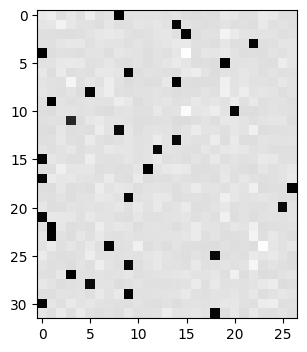

In [22]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray')

In [23]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [24]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 6.984919309616089e-10


#### Put all togather

In [27]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass


In [30]:
with open('names.txt') as f:
    words = f.read().split()
len(words)    

32033

In [34]:
vocabs = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(vocabs)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(stoi)
print(itos)
print(vocab_size)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [37]:
words[0]+'.'

'emma.'

In [43]:
block_size = 3

def build_dataset(words):
    X = []
    Y = []
    for word in words:
        context = [0]*block_size
        word = word + '.'
        for char in word:
            ix = stoi[char]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(f'X shape: {X.shape}, Y shape: {Y.shape}')
    return X,Y

import random
random.seed()
random.shuffle(words)

Xtr, Ytr = build_dataset(words[0: int(0.8*len(words))])
Xdev, Ydev = build_dataset(words[int(0.8*len(words)): int(0.9*len(words))])
Xtst, Ytst = build_dataset(words[int(0.9*len(words)):])

X shape: torch.Size([182385, 3]), Y shape: torch.Size([182385])
X shape: torch.Size([22973, 3]), Y shape: torch.Size([22973])
X shape: torch.Size([22788, 3]), Y shape: torch.Size([22788])
